<a href="https://colab.research.google.com/github/Loopinlogix/Supervised_Learning_Ecommerce/blob/main/Lesson_8_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## ECOMMERCE CUSTOMER CLASSIFICATION — ML ASSIGNMENT
# Predict High vs Low Value Customers

The code builds a full workflow for classifying ecommerce customers into high vs low spenders by generating synthetic data, creating a binary target, doing quick EDA, encoding and scaling features, then training five models; Logistic Regression, Random Forest, SVM, Decision Tree, and KNN—using a shared evaluation function that prints accuracy, precision, recall, F1, ROC AUC, confusion matrices, and reports; finally it compares all models, picks the best one, and plots ROC curves for them.

In [18]:
#github

!apt-get install -y git
!git config --global user.email "crystal_macneil@hotmail.com"
!git config --global user.name "Crystal MacNeil"

!git clone https://github.com/Loopinlogix/Supervised_Learning_Ecommerce.git
%cd /content/Supervised_Learning_Ecommerce

!ls

%cd /content
!rm -rf Supervised_Learning_Ecommerce

!git clone https://github.com/Loopinlogix/Supervised_Learning_Ecommerce.git
%cd /content/Supervised_Learning_Ecommerce
!ls -a




Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git is already the newest version (1:2.34.1-1ubuntu1.17).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.
Cloning into 'Supervised_Learning_Ecommerce'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.
/content/Supervised_Learning_Ecommerce
README.md  Supervised_Learning_Ecommerce
/content
Cloning into 'Supervised_Learning_Ecommerce'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.
/content/Supervised_Learning_Ecommerce
.  ..  .git  README.md


ECOMMERCE CUSTOMER CLASSIFICATION
Output directory: /content/ecommerce_output/

[STEP 1] Dataset created: 500 rows × 8 columns
         Spending range: $983.03 - $2002.74

[STEP 2] Classification threshold (median): $1412.94
         Class distribution:
SpendingClass
0    250
1    250
Name: count, dtype: int64

Preview of target variable:
 Yearly Amount Spent  SpendingClass
         1491.981644              1
         1438.932002              1
         1378.359713              0
         1289.789835              0
         1659.851901              1
         1559.528135              1
         1302.164928              0
         1449.392965              1
         1267.129390              0
         1416.047500              1


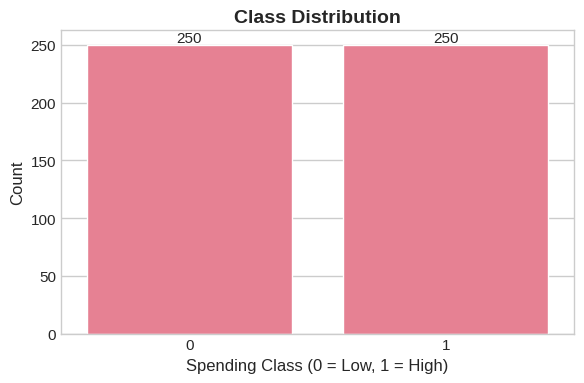

[STEP 3.1] Class distribution plot saved.


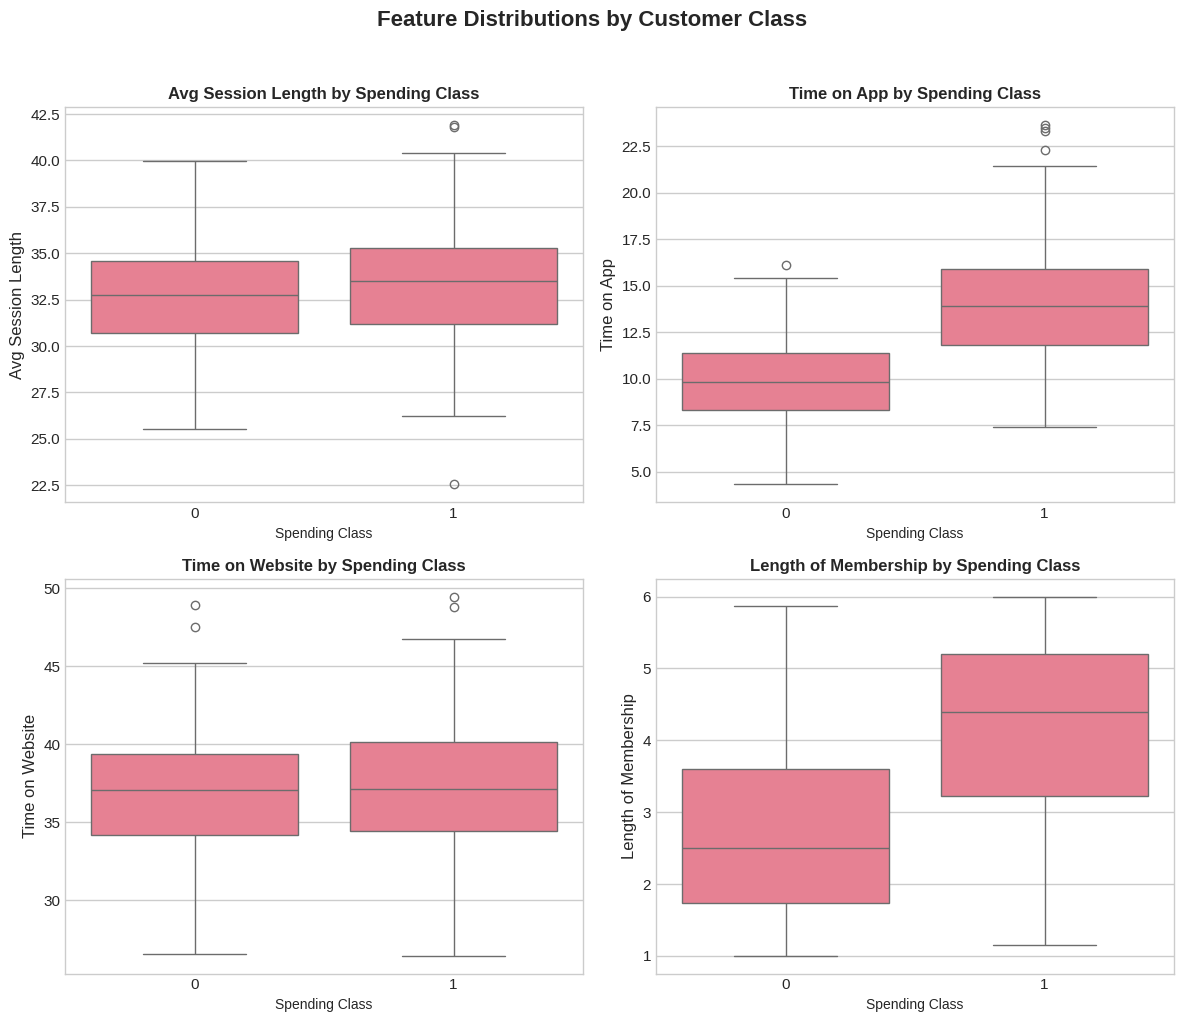

[STEP 3.2] Feature distribution plots saved.


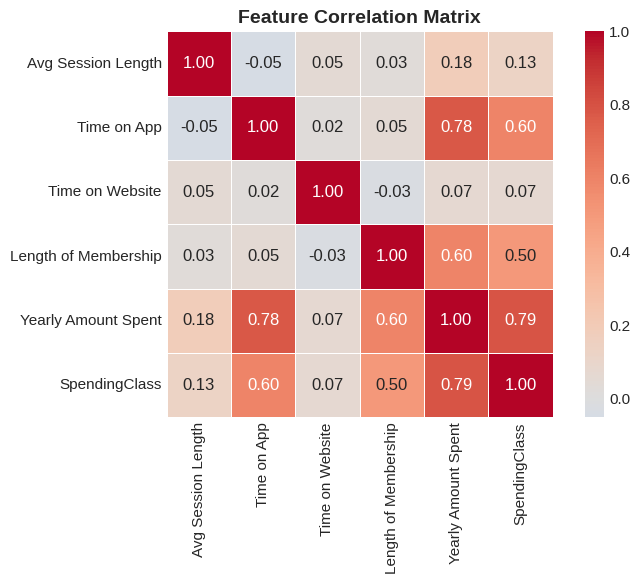

[STEP 3.3] Correlation heatmap saved.

[STEP 4] Features selected (10 total):
          1. Avg Session Length
          2. Time on App
          3. Time on Website
          4. Length of Membership
          5. Avatar_Blue
          6. Avatar_Green
          7. Avatar_Orange
          8. Avatar_Purple
          9. Avatar_Red
         10. Avatar_Yellow

         Train set: 400 samples
         Test set:  100 samples
         Class balance in train: {1: 200, 0: 200}

[STEP 4] Preprocessing complete. Scaler fitted on training data.

MODEL: Logistic Regression
Metric               Value
----------------------------
Accuracy            0.9300
Precision           0.9388
Recall              0.9200
F1_Score            0.9293
ROC_AUC             0.9808

Confusion Matrix:
          Pred 0  Pred 1
Actual 0      47       3
Actual 1       4      46

Classification Report:
              precision    recall  f1-score   support

   Low Value       0.92      0.94      0.93        50
  High Value       

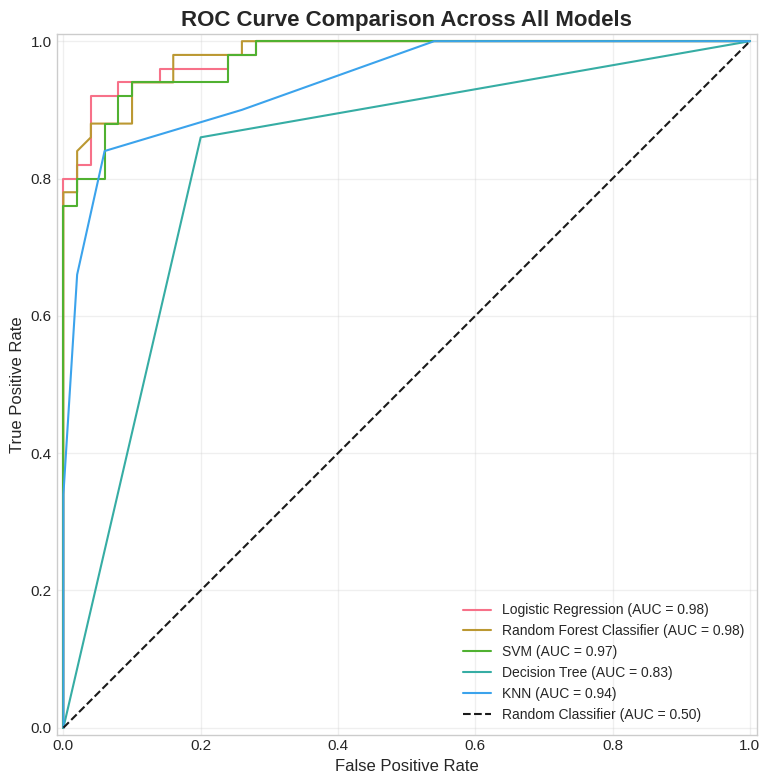

[STEP 7] ROC curves saved to: /content/ecommerce_output/roc_curves.png


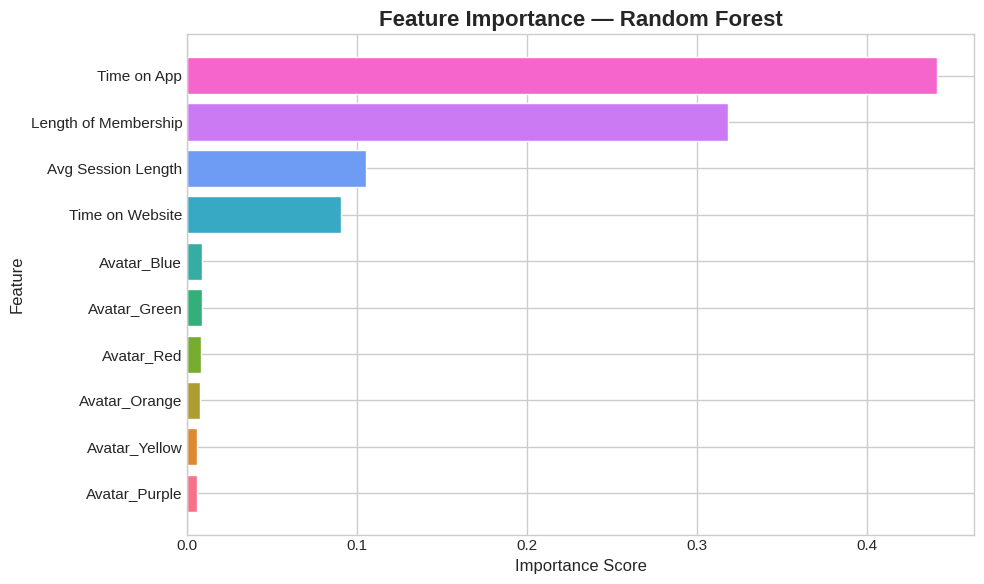

[STEP 8] Feature importance plot saved.

Top 5 Most Important Features:
             Feature  Importance
         Avatar_Blue    0.008980
     Time on Website    0.090613
  Avg Session Length    0.104983
Length of Membership    0.317991
         Time on App    0.440964

WORKFLOW COMPLETE
Total models trained: 5
Best performing model: Logistic Regression (F1 = 0.9293)

All outputs saved to: /content/ecommerce_output/
Files generated:
  • class_distribution.png
  • ecommerce_eda_distributions.png
  • best_model_predictions.csv
  • predictions_vs_actuals.png
  • deployment_strategy.txt
  • roc_curves.png
  • model_results.csv
  • correlation_heatmap.png
  • linear_regression_coefficients.csv
  • feature_distributions.png
  • ecommerce_eda_correlation.png
  • feature_importance.png
  • feature_importance.csv
  • model_comparison.csv
  • model_comparison.png


In [15]:
# ============================================================
# ECOMMERCE CUSTOMER CLASSIFICATION — ML ASSIGNMENT
# Predict High vs Low Value Customers
# Author: Crystal MacNeil
# Date: 2026-06-28
# ============================================================

"""
OBJECTIVE:
    Build and compare multiple classification models to predict whether
    an e-commerce customer is High Value or Low Value based on their
    behavior and profile data.

MODELS EVALUATED:
    - Logistic Regression
    - Random Forest Classifier
    - Support Vector Machine (SVM)
    - Decision Tree
    - K-Nearest Neighbors (KNN)

METRICS:
    - Accuracy, Precision, Recall, F1-Score, ROC-AUC
"""


# ============================================================
# STEP 0: ENVIRONMENT SETUP
# ============================================================

import warnings
warnings.filterwarnings('ignore')

# Core data & visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Scikit-learn utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    RocCurveDisplay
)

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Output directory for saved figures
output_dir = "/content/ecommerce_output/"
os.makedirs(output_dir, exist_ok=True)

print("=" * 70)
print("ECOMMERCE CUSTOMER CLASSIFICATION")
print("=" * 70)
print(f"Output directory: {output_dir}")


# ============================================================
# STEP 1: DATA GENERATION
# ============================================================
"""
Generated synthetic e-commerce data to simulate real customer behavior.
Features include session metrics, time spent on platforms, membership length,
and avatar (categorical). The target (Yearly Amount Spent) is derived from
a weighted combination of features with added noise, then binarized.
"""

np.random.seed(42)
n_customers = 500

# --- Customer profile features ---
data = {
    'Email': [f'customer{i}@email.com' for i in range(n_customers)],
    'Address': [
        f'{np.random.randint(100, 9999)} {np.random.choice(["Main St", "Oak Ave", "Park Blvd", "Elm St"])}'
        for _ in range(n_customers)
    ],
    'Avatar': np.random.choice(
        ['Red', 'Blue', 'Green', 'Orange', 'Purple', 'Yellow'],
        n_customers
    ),
    'Avg Session Length': np.random.normal(33, 3, n_customers),
    'Time on App': np.random.gamma(12, 1, n_customers),
    'Time on Website': np.random.normal(37, 4, n_customers),
    'Length of Membership': np.random.uniform(1, 6, n_customers),
}

df = pd.DataFrame(data)

# --- Generate spending target (regression formula) ---
base_spending = 250
membership_effect = df['Length of Membership'] * 65
app_effect = df['Time on App'] * 38
website_effect = df['Time on Website'] * 2
session_effect = df['Avg Session Length'] * 12

avatar_effect = df['Avatar'].map({
    'Red': 20, 'Blue': 15, 'Green': 10,
    'Orange': 25, 'Purple': 18, 'Yellow': 12
})

noise = np.random.normal(0, 30, n_customers)

df['Yearly Amount Spent'] = (
    base_spending + membership_effect + app_effect +
    website_effect + session_effect + avatar_effect + noise
).clip(lower=50)

print(f"\n[STEP 1] Dataset created: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"         Spending range: ${df['Yearly Amount Spent'].min():.2f} - ${df['Yearly Amount Spent'].max():.2f}")


# ============================================================
# STEP 2: TARGET VARIABLE CREATION (CLASSIFICATION)
# ============================================================
"""
Convert continuous spending into a binary classification problem:
    0 = Low Value Customer  (spending ≤ median)
    1 = High Value Customer (spending > median)
Using the median ensures a balanced dataset (50/50 split).
"""

threshold = df['Yearly Amount Spent'].median()
df['SpendingClass'] = (df['Yearly Amount Spent'] > threshold).astype(int)

print(f"\n[STEP 2] Classification threshold (median): ${threshold:.2f}")
print(f"         Class distribution:\n{df['SpendingClass'].value_counts().sort_index()}")
print(f"\nPreview of target variable:")
print(df[['Yearly Amount Spent', 'SpendingClass']].head(10).to_string(index=False))


# ============================================================
# STEP 3: EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================
"""
Visualize the class distribution and feature distributions to understand
data characteristics before modeling.
"""

# --- 3.1 Class Distribution ---
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x='SpendingClass', data=df, ax=ax)
ax.set_title("Class Distribution", fontsize=14, fontweight='bold')
ax.set_xlabel("Spending Class (0 = Low, 1 = High)", fontsize=12)
ax.set_ylabel("Count", fontsize=12)

# Add count labels on bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.savefig(f"{output_dir}class_distribution.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"[STEP 3.1] Class distribution plot saved.")

# --- 3.2 Feature Distributions by Class ---
numeric_features = ['Avg Session Length', 'Time on App', 'Time on Website', 'Length of Membership']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, feature in enumerate(numeric_features):
    sns.boxplot(x='SpendingClass', y=feature, data=df, ax=axes[idx])
    axes[idx].set_title(f"{feature} by Spending Class", fontsize=12, fontweight='bold')
    axes[idx].set_xlabel("Spending Class", fontsize=10)

plt.suptitle("Feature Distributions by Customer Class", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{output_dir}feature_distributions.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"[STEP 3.2] Feature distribution plots saved.")

# --- 3.3 Correlation Heatmap ---
plt.figure(figsize=(8, 6))
corr_cols = numeric_features + ['Yearly Amount Spent', 'SpendingClass']
corr_matrix = df[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True, linewidths=0.5)
plt.title("Feature Correlation Matrix", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{output_dir}correlation_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"[STEP 3.3] Correlation heatmap saved.")


# ============================================================
# STEP 4: DATA PREPROCESSING
# ============================================================
"""
Prepare data for modeling:
    1. One-hot encode categorical variable (Avatar)
    2. Select relevant features (drop identifiers: Email, Address)
    3. Split into train/test sets (80/20)
    4. Scale features for distance-based models (LR, SVM, KNN)
"""

# --- 4.1 Encode categorical variables ---
df_encoded = pd.get_dummies(df, columns=['Avatar'], drop_first=False)

# --- 4.2 Define feature matrix and target vector ---
feature_cols = [
    'Avg Session Length', 'Time on App', 'Time on Website',
    'Length of Membership'
] + [col for col in df_encoded.columns if col.startswith('Avatar_')]

X = df_encoded[feature_cols]
y = df_encoded['SpendingClass']

print(f"\n[STEP 4] Features selected ({len(feature_cols)} total):")
for i, col in enumerate(feature_cols, 1):
    print(f"         {i:2d}. {col}")

# --- 4.3 Train-test split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n         Train set: {X_train.shape[0]} samples")
print(f"         Test set:  {X_test.shape[0]} samples")
print(f"         Class balance in train: {y_train.value_counts().to_dict()}")

# --- 4.4 Feature scaling ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n[STEP 4] Preprocessing complete. Scaler fitted on training data.")


# ============================================================
# STEP 5: MODEL TRAINING & EVALUATION
# ============================================================
"""
Train 5 classification models and evaluate using standard metrics.
Each model is evaluated on the same test set for fair comparison.
"""

def evaluate_classifier(model, X_tr, X_te, y_tr, y_te, name, use_scaled=False):
    """
    Trains a classifier and computes comprehensive evaluation metrics.

    Parameters:
        model: sklearn estimator
        X_tr, X_te: training and test features
        y_tr, y_te: training and test labels
        name: model name for display
        use_scaled: whether model requires scaled features

    Returns:
        trained_model, metrics_dict
    """
    print(f"\n{'='*60}")
    print(f"MODEL: {name}")
    print(f"{'='*60}")

    # Train
    model.fit(X_tr, y_tr)

    # Predict
    y_pred = model.predict(X_te)

    # Probability scores for ROC-AUC (if available)
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_te)[:, 1]
    else:
        y_prob = None

    # Compute metrics
    metrics = {
        'Model': name,
        'Accuracy': accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred),
        'Recall': recall_score(y_te, y_pred),
        'F1_Score': f1_score(y_te, y_pred),
        'ROC_AUC': roc_auc_score(y_te, y_prob) if y_prob is not None else np.nan
    }

    # Display results
    print(f"{'Metric':<15} {'Value':>10}")
    print("-" * 28)
    for k, v in metrics.items():
        if k != 'Model':
            print(f"{k:<15} {v:>10.4f}")

    print(f"\nConfusion Matrix:")
    cm = confusion_matrix(y_te, y_pred)
    print(pd.DataFrame(cm, index=['Actual 0', 'Actual 1'],
                       columns=['Pred 0', 'Pred 1']).to_string())

    print(f"\nClassification Report:")
    print(classification_report(y_te, y_pred, target_names=['Low Value', 'High Value']))

    return model, metrics


# --- Model 1: Logistic Regression ---
lr = LogisticRegression(max_iter=5000, random_state=42)
lr_model, lr_metrics = evaluate_classifier(
    lr, X_train_scaled, X_test_scaled, y_train, y_test,
    "Logistic Regression", use_scaled=True
)

# --- Model 2: Random Forest ---
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model, rf_metrics = evaluate_classifier(
    rf, X_train, X_test, y_train, y_test,
    "Random Forest Classifier", use_scaled=False
)

# --- Model 3: Support Vector Machine ---
svm = SVC(probability=True, random_state=42)
svm_model, svm_metrics = evaluate_classifier(
    svm, X_train_scaled, X_test_scaled, y_train, y_test,
    "SVM", use_scaled=True
)

# --- Model 4: Decision Tree ---
dt = DecisionTreeClassifier(random_state=42)
dt_model, dt_metrics = evaluate_classifier(
    dt, X_train, X_test, y_train, y_test,
    "Decision Tree", use_scaled=False
)

# --- Model 5: K-Nearest Neighbors ---
knn = KNeighborsClassifier(n_neighbors=5)
knn_model, knn_metrics = evaluate_classifier(
    knn, X_train_scaled, X_test_scaled, y_train, y_test,
    "KNN", use_scaled=True
)


# ============================================================
# STEP 6: MODEL COMPARISON & RESULTS
# ============================================================
"""
Aggregate all model results into a comparison table and identify
the best performing model based on F1-Score.
"""

results_list = [lr_metrics, rf_metrics, svm_metrics, dt_metrics, knn_metrics]
results_df = pd.DataFrame(results_list)

# Reorder columns for readability
results_df = results_df[['Model', 'Accuracy', 'Precision', 'Recall', 'F1_Score', 'ROC_AUC']]

print("\n" + "=" * 70)
print("MODEL COMPARISON SUMMARY")
print("=" * 70)
print(results_df.to_string(index=False))

# Identify best model
best_idx = results_df['F1_Score'].idxmax()
best_model_name = results_df.loc[best_idx, 'Model']
best_f1 = results_df.loc[best_idx, 'F1_Score']

print(f"\n{'='*70}")
print(f"BEST MODEL: {best_model_name}")
print(f"BEST F1-SCORE: {best_f1:.4f}")
print(f"{'='*70}")

# Save results to CSV
results_df.to_csv(f"{output_dir}model_comparison.csv", index=False)
print(f"\n[STEP 6] Results saved to: {output_dir}model_comparison.csv")


# ============================================================
# STEP 7: ROC CURVE COMPARISON
# ============================================================
"""
Plot ROC curves for all models on a single chart to visually compare
discriminative ability. Models requiring scaled data use scaled test set.
"""

plt.figure(figsize=(10, 8))

models_to_plot = {
    'Logistic Regression': (lr_model, X_test_scaled),
    'Random Forest Classifier': (rf_model, X_test),
    'SVM': (svm_model, X_test_scaled),
    'Decision Tree': (dt_model, X_test),
    'KNN': (knn_model, X_test_scaled)
}

for name, (model, X_eval) in models_to_plot.items():
    try:
        RocCurveDisplay.from_estimator(
            model, X_eval, y_test,
            name=name, ax=plt.gca()
        )
    except Exception as e:
        print(f"Warning: Could not plot ROC for {name}: {e}")

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.50)')
plt.title("ROC Curve Comparison Across All Models", fontsize=16, fontweight='bold')
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{output_dir}roc_curves.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"[STEP 7] ROC curves saved to: {output_dir}roc_curves.png")


# ============================================================
# STEP 8: FEATURE IMPORTANCE (Best Model: Random Forest)
# ============================================================
"""
Extract and visualize feature importances from the Random Forest model
to understand which features drive customer value predictions.
"""

# Get feature importances
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances
}).sort_values('Importance', ascending=True)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'],
         color=sns.color_palette("husl", len(feature_importance_df)))
plt.title("Feature Importance — Random Forest", fontsize=16, fontweight='bold')
plt.xlabel("Importance Score", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.tight_layout()
plt.savefig(f"{output_dir}feature_importance.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"[STEP 8] Feature importance plot saved.")

# Display top features
print(f"\nTop 5 Most Important Features:")
print(feature_importance_df.tail(5).to_string(index=False))


# ============================================================
# STEP 9: FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("WORKFLOW COMPLETE")
print("=" * 70)
print(f"Total models trained: {len(results_df)}")
print(f"Best performing model: {best_model_name} (F1 = {best_f1:.4f})")
print(f"\nAll outputs saved to: {output_dir}")
print("Files generated:")
for f in os.listdir(output_dir):
    print(f"  • {f}")
print("=" * 70)
